## Business Understanding

### Background

A multinational e-commerce platform serves customers across multiple countries. The platform tracks detailed behavioral data for each
user including login frequency, session duration, purchase history, cart
abandonment, and engagement across email/mobile/social channels.

While the platform has a large and active user base (49,381 users after
data cleaning), the overall churn rate stands at 28.65% — nearly 1 in 3
users stop engaging with the platform. Leadership currently treats all
users with a uniform retention strategy, without distinguishing between
highly engaged users and users who are already at risk of leaving.

This project was initiated to segment users based on behavioral patterns,
quantify how churn risk and customer value differ across segments, and
provide a data-driven basis for prioritizing retention efforts.

### Business Problem

The platform currently lacks a clear, data-driven answer to the following:

- Are all users equally likely to churn, or are there identifiable behavioral
  segments with meaningfully different churn risk?
- Do these segments also differ in customer value (Lifetime Value), or is
  churn risk unrelated to revenue contribution?
- Which segment should be prioritized for retention investment to protect
  the most revenue at the lowest cost?

Without this segmentation, retention budget risks being spent evenly across
all users — including low-value users unlikely to churn, while high-risk,
high-value users receive no targeted attention.

### Project Objectives

1. Clean and prepare 12 months of user behavioral data for analysis.
2. Segment users into behavioral tiers using unsupervised clustering (K-Means).
3. Quantify churn rate and Lifetime Value for each segment.
4. Identify which segment represents the highest retention risk and the
   highest revenue opportunity.
5. Translate the segmentation into specific, actionable retention recommendations.

## Data Understanding

In [2]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path = kagglehub.dataset_download("dhairyajeetsingh/ecommerce-customer-behavior-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 1.96M/1.96M [00:00<00:00, 127MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset/versions/1
['ecommerce_customer_churn_dataset.csv']


In [3]:
file_path = os.path.join(path, "ecommerce_customer_churn_dataset.csv")
df = pd.read_csv(file_path)

In [4]:
df.shape

(50000, 25)

In [5]:
df.head(10)

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4
5,35.0,Male,Japan,Tokyo,3.5,6.0,21.9,6.9,74.4,0.0,...,16.0,8.0,2.0,14.3,11.2,2.0,1995.43,2418.0,1,Q1
6,56.0,Male,Germany,Berlin,1.9,24.0,46.4,13.9,36.2,5.0,...,35.5,4.0,6.0,68.8,42.9,5.0,3003.57,2657.0,0,Q1
7,47.0,Female,USA,Houston,1.6,14.0,24.1,8.3,59.9,2.0,...,5.5,5.0,NaN,30.1,7.6,2.0,1394.04,2274.0,0,Q4
8,32.0,Male,Canada,Calgary,1.3,14.0,NaN,7.4,66.5,4.0,...,19.0,2.0,0.0,0.0,18.7,2.0,537.21,534.0,0,Q1
9,44.0,Male,USA,New York,3.6,13.0,31.3,5.4,62.6,3.0,...,11.7,2.0,1.0,13.5,21.5,2.0,807.84,977.0,0,Q2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [7]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


- The dataset contains 50,000 rows and 24 columns, covering user demographics (Age, Gender, Country, City), engagement behavior (Login_Frequency, Session_Duration_Avg, Pages_Per_Session, Mobile_App_Usage, Email_Open_Rate, Social_Media_Engagement_Score), transaction behavior (Total_Purchases, Average_Order_Value, Discount_Usage_Rate, Cart_Abandonment_Rate, Returns_Rate), and outcome variables (Lifetime_Value, Churned).
- The target variable for churn analysis is `Churned` (binary: 0 = active, 1 = churned), with an overall churn rate of 28.65% across the raw dataset.
- 12 out of 24 columns contain missing values, ranging from 0.3%
(Customer_Service_Calls) to 12% (Social_Media_Engagement_Score) — no column
exceeds 15% missing, meaning imputation is a viable strategy rather than  requiring rows or columns to be dropped entirely.
- Initial inspection via df.describe() revealed data quality issues that need to be addressed before analysis: Age has a maximum of 200 (implausible), Total_Purchases includes negative values (invalid for a count metric), and Cart_Abandonment_Rate exceeds 100% in some records (invalid for a percentage) — these are flagged here and resolved in the Data Cleaning step below.
- `Signup_Quarter` and `Membership_Years` provide tenure-related context that can later be used to understand whether churn risk is tied to how long a user has been on the platform, in addition to their behavioral activity level.

## Data Cleaning

In [8]:
df.isnull().sum()
null_percent = df.isnull().mean() * 100
print(null_percent.sort_values(ascending=False))

Social_Media_Engagement_Score    12.000
Credit_Balance                   11.000
Mobile_App_Usage                 10.000
Returns_Rate                      8.982
Wishlist_Items                    8.000
Product_Reviews_Written           7.000
Discount_Usage_Rate               7.000
Session_Duration_Avg              6.798
Pages_Per_Session                 6.000
Days_Since_Last_Purchase          6.000
Email_Open_Rate                   5.056
Payment_Method_Diversity          5.000
Age                               4.990
Customer_Service_Calls            0.336
Gender                            0.000
Country                           0.000
Membership_Years                  0.000
Cart_Abandonment_Rate             0.000
Login_Frequency                   0.000
City                              0.000
Average_Order_Value               0.000
Total_Purchases                   0.000
Lifetime_Value                    0.000
Churned                           0.000
Signup_Quarter                    0.000


In [9]:
#1-5%
columns_to_impute = ['Customer_Service_Calls', 'Age', 'Payment_Method_Diversity', 'Email_Open_Rate']
for col in columns_to_impute:
    df[col] = df[col].fillna(df[col].median())

#5-10%
df['Activity_Tier'] = pd.qcut(df['Login_Frequency'], q=5, labels=[1, 2, 3, 4, 5])
column_to_impute1 = ['Session_Duration_Avg', 'Product_Reviews_Written', 'Wishlist_Items', 'Pages_Per_Session']
for col in column_to_impute1:
    df[col] = df.groupby('Activity_Tier', observed=False)[col].transform(lambda x: x.fillna(x.median()))

df['Membership_Tier'] = pd.qcut(df['Membership_Years'], q=3, labels=['New_User', 'Regular_User', 'Loyal_User'])
df['Discount_Usage_Rate'] = df.groupby('Membership_Tier', observed=False)['Discount_Usage_Rate'].transform(lambda x: x.fillna(x.median()))
df['Returns_Rate'] = df.groupby('Customer_Service_Calls')['Returns_Rate'].transform(lambda x: x.fillna(x.median()))
df['Days_Since_Last_Purchase'] = df.groupby('Churned')['Days_Since_Last_Purchase'].transform(lambda x: x.fillna(x.median()))

#10-12%
df['SM_missing'] = df['Social_Media_Engagement_Score'].isnull().astype(int)
df['App_missing'] = df['Mobile_App_Usage'].isnull().astype(int)
df['Credit_missing'] = df['Credit_Balance'].isnull().astype(int)

high_missing_cols = ['Social_Media_Engagement_Score', 'Mobile_App_Usage']
for col in high_missing_cols:
    df[col] = df.groupby('Activity_Tier', observed=False)[col].transform(lambda x: x.fillna(x.median()))

df['Credit_Balance'] = df['Credit_Balance'].fillna(0)

df.drop(columns=['Membership_Tier'], inplace=True)
df.drop(columns=['Activity_Tier'], inplace=True)


In [10]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,SM_missing,App_missing,Credit_missing
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,37.812800,2.984009,11.624660,27.353578,8.735973,57.079973,4.282880,13.111576,123.117330,29.269060,...,2.835320,29.237210,19.363318,2.33618,1440.626292,1749.947600,0.289000,0.120000,0.100000,0.110000
std,11.535688,2.059105,7.810657,10.647001,3.711174,16.282723,3.097672,7.017312,175.569714,28.875553,...,2.275044,19.760739,9.149380,1.08465,907.249443,1309.277071,0.453302,0.324965,0.300003,0.312893
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.400000,6.000000,19.400000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,1.000000,13.600000,12.600000,2.00000,789.817500,647.000000,0.000000,0.000000,0.000000,0.000000
50%,38.000000,2.500000,11.000000,26.400000,8.400000,58.100000,4.000000,12.000000,112.970000,20.000000,...,2.000000,27.200000,18.600000,2.00000,1243.415000,1697.000000,0.000000,0.000000,0.000000,0.000000
75%,45.000000,4.000000,17.000000,34.100000,11.100000,68.700000,6.000000,17.000000,144.440000,39.000000,...,4.000000,42.500000,25.300000,3.00000,1874.000000,2664.000000,1.000000,0.000000,0.000000,0.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,21.000000,100.000000,61.900000,5.00000,8987.240000,7197.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
df = df[(df['Age'] >= 12) & (df['Age'] <= 90)]
df = df[df['Total_Purchases'] >= 0]
df = df[df['Cart_Abandonment_Rate'] <= 100]

q_high = df['Average_Order_Value'].quantile(0.99)
df = df[df['Average_Order_Value'] < q_high]


In [12]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,SM_missing,App_missing,Credit_missing
count,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,...,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000
mean,37.782609,2.982930,11.630202,27.361710,8.740392,57.033229,4.286365,13.131654,117.821935,29.279439,...,2.835119,29.258267,19.372176,2.336769,1422.655186,1751.163747,0.286527,0.119884,0.100099,0.109921
std,11.165671,2.057075,7.814457,10.651151,3.710558,16.213993,3.099529,7.006998,41.548701,28.881621,...,2.275388,19.760663,9.150139,1.084740,880.057217,1309.993017,0.452143,0.324829,0.300135,0.312794
min,18.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.400000,6.000000,19.400000,6.000000,46.400000,2.000000,8.000000,86.780000,9.000000,...,1.000000,13.600000,12.600000,2.000000,785.250000,648.000000,0.000000,0.000000,0.000000,0.000000
50%,38.000000,2.500000,11.000000,26.400000,8.400000,58.100000,4.000000,12.000000,112.380000,20.000000,...,2.000000,27.200000,18.600000,2.000000,1234.020000,1699.000000,0.000000,0.000000,0.000000,0.000000
75%,45.000000,4.000000,17.000000,34.200000,11.100000,68.700000,6.000000,17.000000,143.230000,39.000000,...,4.000000,42.500000,25.300000,3.000000,1856.250000,2665.000000,1.000000,0.000000,0.000000,0.000000
max,75.000000,10.000000,46.000000,75.600000,24.100000,100.000000,28.000000,128.700000,252.020000,287.000000,...,21.000000,100.000000,61.900000,5.000000,8023.200000,7197.000000,1.000000,1.000000,1.000000,1.000000


- The dataset originally contained 50,000 rows with missing values ranging
  from 0.3% (Customer_Service_Calls) to 12% (Social_Media_Engagement_Score)
  across 12 columns. No column exceeded 15% missing, so all rows were retained and imputation was used instead of dropping data.
- Imputation strategy was tiered by missing severity: columns with < 5% missing were filled with the global median; columns with 5-10% missing were filled with the median within a relevant behavioral group (e.g., Discount_Usage_Rate by Membership_Tier) to preserve within-segment patterns; columns with >10% missing were flagged with a missing-indicator column in addition to group-median imputation, in case missingness itself is informative.
- Outlier checks revealed clear data quality issues rather than natural extreme values: Age reached an implausible maximum of 200, Total_Purchases included negative values (impossible for a count), and Cart_Abandonment_Rate exceeded 100% in some rows (invalid for a percentage metric). These were removed as invalid records rather than treated as statistical outliers.
- Average_Order_Value had a small number of extreme values (max \$9,666 vs a
  median of ~$113); the top 1% was trimmed to prevent these from distorting
  aggregate metrics.
- After cleaning, the dataset was reduced from 50,000 to 49,381 rows (1.2%
  removed), all due to invalid values rather than legitimate data loss.

In [13]:
df.to_csv('customer_behav.csv', index=False)

## User Behavior

### Correlation Analysis

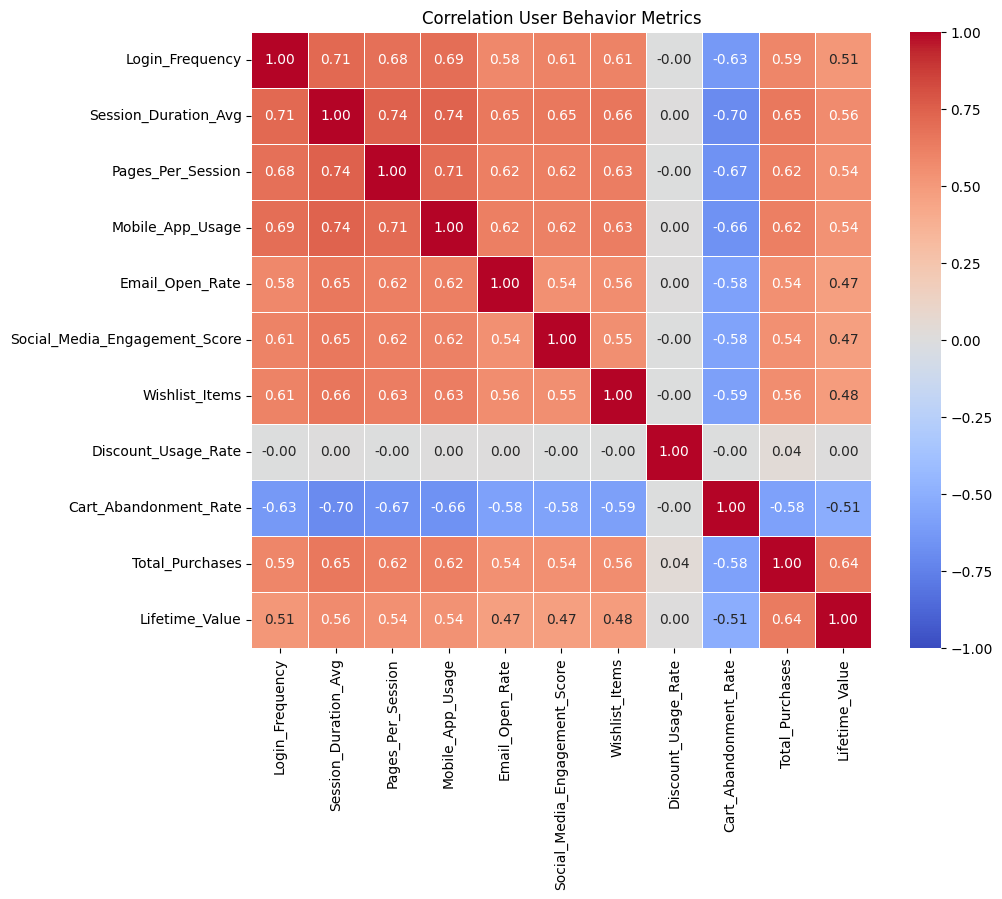

In [29]:
behavior_metrics = ['Login_Frequency',
    'Session_Duration_Avg',
    'Pages_Per_Session',
    'Mobile_App_Usage',
    'Email_Open_Rate',
    'Social_Media_Engagement_Score',
    'Wishlist_Items',
    'Discount_Usage_Rate',
    'Cart_Abandonment_Rate',
    'Total_Purchases',
    'Lifetime_Value']
correlation_matrix = df[behavior_metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation User Behavior Metrics')
plt.show()

- Login_Frequency, Session_Duration_Avg, Total_Purchases, and Lifetime_Value show a consistent positive relationship with one another — users who log in more often also tend to spend more time per session, purchase more, and generate higher lifetime value.
- Cart_Abandonment_Rate shows a negative relationship with these same engagement metrics — more engaged users abandon their carts less frequently.
- This pattern supports using login frequency, session duration, and purchase count as the core features for behavioral segmentation, since they move together and capture a consistent "engagement" signal rather than measuring unrelated behaviors.

### Clustering - Elbow Method

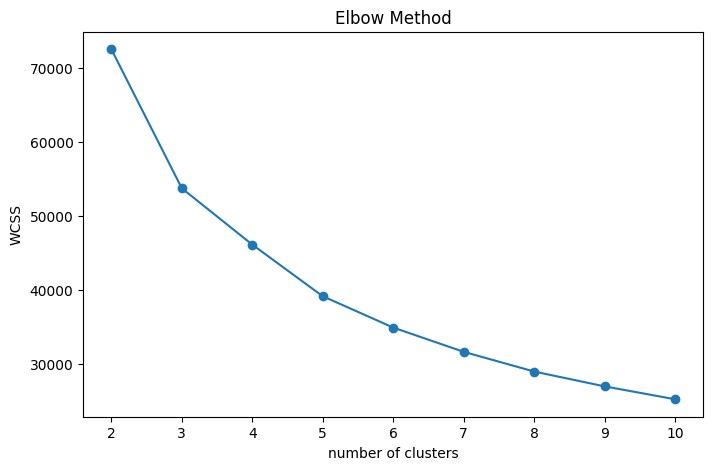

              Login_Frequency  Session_Duration_Avg  Total_Purchases  \
User_Segment                                                           
Segment 1                5.08                 18.36             8.06   
Segment 2               13.37                 29.56            14.02   
Segment 3               22.47                 42.66            22.53   

              Lifetime_Value  Days_Since_Last_Purchase  Cart_Abandonment_Rate  \
User_Segment                                                                    
Segment 1             889.75                     28.95                  68.00   
Segment 2            1546.83                     29.55                  54.60   
Segment 3            2341.77                     29.42                  37.85   

              Churned  
User_Segment           
Segment 1        0.40  
Segment 2        0.21  
Segment 3        0.20  


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

behavior_features = ['Login_Frequency', 'Session_Duration_Avg', 'Total_Purchases',]
X = df[behavior_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['User_Segment'] = kmeans.fit_predict(X_scaled)

cluster_number_mapping = {0: 'Segment 1', 1: 'Segment 2', 2: 'Segment 3'}
df['User_Segment'] = df['User_Segment'].map(cluster_number_mapping)

segment_profile = df.groupby('User_Segment')[['Login_Frequency', 'Session_Duration_Avg', 'Total_Purchases', 'Lifetime_Value', 'Days_Since_Last_Purchase', 'Cart_Abandonment_Rate', 'Churned']].mean()
print(segment_profile.round(2))

- The within-cluster sum of squares (WCSS) shows a clear bend around k=3,
  after which additional clusters yield diminishing reduction in WCSS.
- k=3 was selected as it balances interpretability (three actionable tiers:
  Low, Moderate, High Activity) with statistical justification from the elbow
  point, rather than being chosen arbitrarily.

### Clustering — Silhouette Score Validation

In [18]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: silhouette score = {score:.3f}")

k=2: silhouette score = 0.447
k=3: silhouette score = 0.350
k=4: silhouette score = 0.289
k=5: silhouette score = 0.290


While k=2 produced the highest silhouette score (0.447) compared to k=3
(0.350), k=3 was retained as the final model. A 2-cluster solution likely
captures only a broad "active vs. inactive" split, whereas k=3 provides
three distinct engagement tiers that map directly to differentiated retention
strategies (win-back, engagement-building, and loyalty programs). This
reflects a deliberate trade-off: prioritizing business actionability over
marginal gains in statistical cluster separation. The consistent drop in
silhouette score beyond k=3, and the plateau between k=4 and k=5
(0.289 vs. 0.290), further confirms that no meaningful additional structure
exists beyond three segments.

In [33]:
segment_label_mapping = {'Segment 1':'Low Activity User', 'Segment 2':'Moderately Active Users', 'Segment 3':'High Activity Users'}
df['User_Segment'] = df['User_Segment'].replace(segment_label_mapping)

In [20]:
df['User_Segment'].value_counts()

,count
User_Segment,
Low Activity User,20363
Moderately Active Users,19900
High Activity Users,9118


### Behavioral Profile by Segment

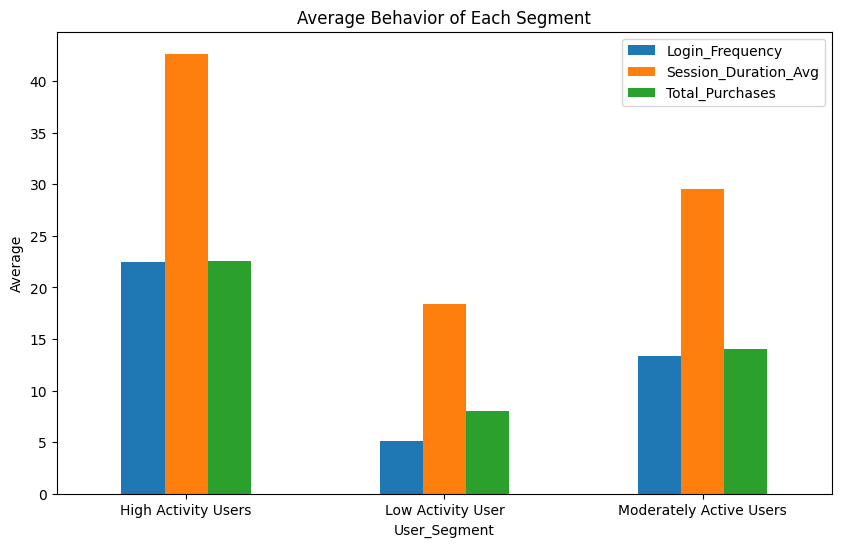

In [30]:
profile = df.groupby('User_Segment')[
    behavior_features
].mean()

profile.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average Behavior of Each Segment")
plt.ylabel("Average")
plt.xticks(rotation=0)
plt.show()

The three segments show clear separation across all three clustering features:

- Low Activity User (20,363 users, 41.2%): Login_Frequency ~5.1, Session_Duration_Avg ~18.4 min, Total_Purchases ~8.1
- Moderately Active Users (19,900 users, 40.3%): Login_Frequency ~13.4,
Session_Duration_Avg ~29.6 min, Total_Purchases ~14.0
- High Activity Users (9,118 users, 18.5%): Login_Frequency ~22.5, Session_Duration_Avg ~42.7 min, Total_Purchases ~22.5
- High Activity Users are the smallest segment (18.5% of the user base) but
show roughly 4x the login frequency and nearly 3x the purchases of Low Activity Users, confirming the clustering captured a meaningful behavioral gradient rather than an arbitrary split.

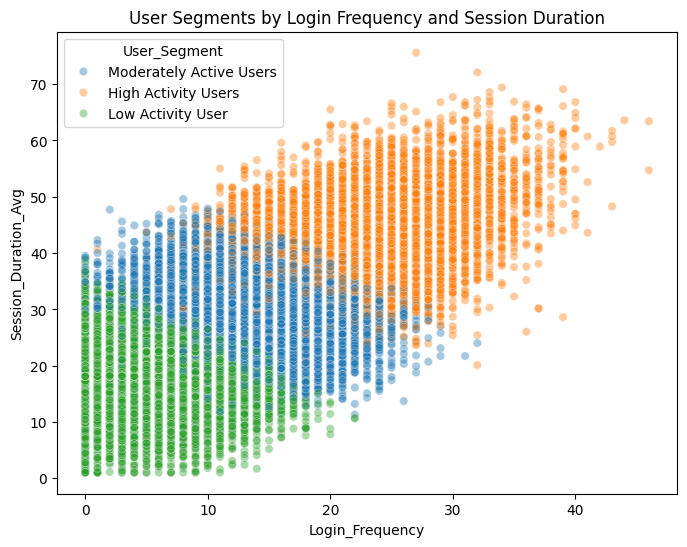

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Login_Frequency', y='Session_Duration_Avg', hue='User_Segment', alpha=0.4)
plt.title("User Segments by Login Frequency and Session Duration")
plt.show()

- Age (37.7-37.8 years) and Membership_Years (~3 years) show virtually no
  variation across the three segments, indicating that engagement level is
  not explained by how old a user is or how long they've been a member.
- Country distribution is also nearly identical across segments (USA ~35%,
  UK ~15% in each), ruling out geography as a differentiating factor.
- This confirms that behavioral segmentation captures something demographic
  data alone cannot: engagement level must be identified through activity
  tracking (login frequency, session duration, purchases), not through
  static customer profile attributes. This has a direct implication for
  targeting — campaigns cannot simply filter by age or country to find
  at-risk users; they need behavioral data pipelines.

### Churn Rate by Segment

In [ ]:
churn_segment = df.groupby('User_Segment')['Churned'].mean()*100

print(churn_segment.round(2))

User_Segment
High Activity Users        19.65
Low Activity User          39.88
Moderately Active Users    21.29
Name: Churned, dtype: float64


- Churn rate differs sharply across segments: Low Activity Users churn at
  39.88%, more than double the rate of High Activity Users (19.65%).
  Moderately Active Users sit in between at 21.29%.
- This confirms that churn risk is not evenly distributed — it is concentrated
  in the least engaged segment, which also happens to be the largest segment
  by user count (41.2% of all users).

### Demographic Profile by Segment

In [27]:
df.groupby('User_Segment')[['Age', 'Membership_Years']].mean()


,Age,Membership_Years
User_Segment,,
High Activity Users,37.757622,2.980618
Low Activity User,37.812847,2.988808
Moderately Active Users,37.763116,2.977975


In [28]:
df.groupby('User_Segment')['Country'].value_counts(normalize=True)

User_Segment             Country  
High Activity Users      USA          0.346129
                         UK           0.153542
                         Canada       0.114937
                         Germany      0.098596
                         France       0.084777
                         Australia    0.079074
                         India        0.071288
                         Japan        0.051656
Low Activity User        USA          0.348623
                         UK           0.151500
                         Canada       0.122870
                         Germany      0.096204
                         France       0.080882
                         Australia    0.080735
                         India        0.069783
                         Japan        0.049403
Moderately Active Users  USA          0.346834
                         UK           0.148844
                         Canada       0.120402
                         Germany      0.101055
                         Australia    0.082814
                         France       0.077487
                         India        0.070050
                         Japan        0.052513
Name: proportion, dtype: float64

### Lifetime Value by Segment

In [ ]:
ltv_segment = df.groupby('User_Segment')[
    'Lifetime_Value'
].mean()

print(ltv_segment)

User_Segment
High Activity Users        2341.765560
Low Activity User           889.753544
Moderately Active Users    1546.827434
Name: Lifetime_Value, dtype: float64


- Lifetime Value also scales with activity level: Low Activity Users average \$889.75, Moderately Active Users average \$1,546.83, and High Activity Users average \$2,341.77 — a 2.6x gap between the lowest and highest segment.
- Combined with the churn findings, this shows the platform's highest-risk
segment (Low Activity, 39.88% churn) is also its lowest-value segment per
user — but because it's the largest segment by count, it still represents
the platform's single largest pool of at-risk revenue.

### Segment Summary

In [25]:
segment_summary = pd.DataFrame({
    'User_Count': df['User_Segment'].value_counts(),
    'Percentage': (df['User_Segment'].value_counts(normalize=True) * 100).round(1),
    'Avg_Login_Frequency': df.groupby('User_Segment')['Login_Frequency'].mean().round(1),
    'Avg_Session_Duration': df.groupby('User_Segment')['Session_Duration_Avg'].mean().round(1),
    'Avg_Total_Purchases': df.groupby('User_Segment')['Total_Purchases'].mean().round(1),
    'Avg_LTV': df.groupby('User_Segment')['Lifetime_Value'].mean().round(2),
    'Churn_Rate_%': (df.groupby('User_Segment')['Churned'].mean() * 100).round(2)
})


priority_action = {
    'Low Activity User': 'Win-back campaign (largest churn risk pool)',
    'Moderately Active Users': 'Engagement-building nudges (move toward High tier)',
    'High Activity Users': 'VIP / loyalty program (protect high-value users)'
}
segment_summary['Priority_Action'] = segment_summary.index.map(priority_action)

segment_summary = segment_summary.sort_values('User_Count', ascending=False)

segment_summary

,User_Count,Percentage,Avg_Login_Frequency,Avg_Session_Duration,Avg_Total_Purchases,Avg_LTV,Churn_Rate_%,Priority_Action
User_Segment,,,,,,,,
Low Activity User,20363,41.2,5.1,18.4,8.1,889.75,39.88,Win-back campaign (largest churn risk pool)
Moderately Active Users,19900,40.3,13.4,29.6,14.0,1546.83,21.29,Engagement-building nudges (move toward High t...
High Activity Users,9118,18.5,22.5,42.7,22.5,2341.77,19.65,VIP / loyalty program (protect high-value users)


## Business Insight & Recomendation

1. Low Activity Users are the platform's largest churn risk pool
* Finding: Low Activity Users make up 41.2% of the user base (20,363 users) and churn at 39.88% — roughly double the rate of Moderately Active (21.29%) and High Activity Users (19.65%).
* Impact: At current rates, an estimated ~8,100 Low Activity Users churn, compared to ~4,240 Moderate and ~1,790 High Activity users — making this segment the single largest source of user loss on the platform, both in count and proportion.
* Recommendation: Prioritize re-engagement campaigns (e.g., win-back emails, personalized product recommendations, limited-time incentives) specifically for Low Activity Users, since this segment offers the largest volume of preventable churn.

2. Engagement level is directly tied to customer value, not just churn
* Finding: Lifetime Value rises consistently with activity level — \$889.75 (Low) → \$1,546.83 (Moderate) → \$2,341.77 (High), a 2.6x difference between the lowest and highest segment.
* Impact: Moving users up even one tier — from Low to Moderate — represents a potential uplift of ~$657 in average Lifetime Value per user. Applied across the Low Activity segment, this represents a substantial (though illustrative) revenue opportunity, underscoring that engagement-building initiatives can be justified as a revenue lever, not just a retention cost.
* Recommendation: Introduce engagement-building nudges (e.g., app push notifications, gamified login streaks, personalized content) aimed at moving Low Activity Users into the Moderate tier, rather than only focusing retention efforts on stopping churn after the fact.

3. High Activity Users are the smallest but most valuable segment — protect, don't just acquire
* Finding: High Activity Users make up only 18.5% of users but have both the lowest churn rate (19.65%) and highest Lifetime Value ($2,341.77).
* Impact: Losing a High Activity User is disproportionately costly relative to its low likelihood — this segment should not be deprioritized simply because its churn numbers look small in absolute terms.
* Recommendation: Implement a loyalty or VIP program for High Activity Users to protect this high-value segment, since the cost of retaining them is likely lower than the value at risk if they churn.

4. Engagement metrics move together — a single composite "engagement score" could simplify targeting
* Finding: Login frequency, session duration, purchase count, and Lifetime Value are all positively correlated, while Cart_Abandonment_Rate moves inversely with all of them.
* Impact: Because these metrics move together, marketing and product teams don't need to track each metric separately to identify at-risk users — a simplified engagement score could serve as an early-warning signal.
* Recommendation: Develop a composite engagement score (e.g., weighted combination of login frequency, session duration, and cart abandonment) to flag users drifting toward the Low Activity tier before they churn, enabling proactive rather than reactive retention.